In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

In [ ]:
os.makedirs("results/task2", exist_ok=True)

In [ ]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print(X.shape)
print(y.value_counts())

(569, 30)
1    357
0    212
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
def add_label_noise(labels, noise_percentage):

    noisy_labels = labels.copy()

    n_samples = len(labels)

    n_noisy = int(noise_percentage * n_samples)

    random_indices = np.random.choice(
        n_samples,
        n_noisy,
        replace=False
    )

    noisy_labels.iloc[random_indices] = 1 - noisy_labels.iloc[random_indices]

    return noisy_labels

In [ ]:
noise_levels = [0, 10, 20, 30]

results = []

for noise in noise_levels:

    y_train_noisy = add_label_noise(
        y_train,
        noise / 100
    )

    models = {

        "Logistic Regression": LogisticRegression(max_iter=500),

        "Decision Tree": DecisionTreeClassifier(random_state=42),

        "Random Forest": RandomForestClassifier(
            n_estimators=100,
            random_state=42
        )
    }

    for model_name, model in models.items():

        model.fit(X_train, y_train_noisy)

        predictions = model.predict(X_test)

        accuracy = accuracy_score(y_test, predictions)

        results.append({
            "Noise (%)": noise,
            "Model": model_name,
            "Accuracy": accuracy
        })

In [ ]:
results_df = pd.DataFrame(results)

print(results_df)

results_df.to_csv(
    "results/task2/noise_comparison.csv",
    index=False
)

    Noise (%)                Model  Accuracy
0           0  Logistic Regression  0.982456
1           0        Decision Tree  0.912281
2           0        Random Forest  0.956140
3          10  Logistic Regression  0.938596
4          10        Decision Tree  0.859649
5          10        Random Forest  0.956140
6          20  Logistic Regression  0.912281
7          20        Decision Tree  0.815789
8          20        Random Forest  0.964912
9          30  Logistic Regression  0.894737
10         30        Decision Tree  0.675439
11         30        Random Forest  0.859649


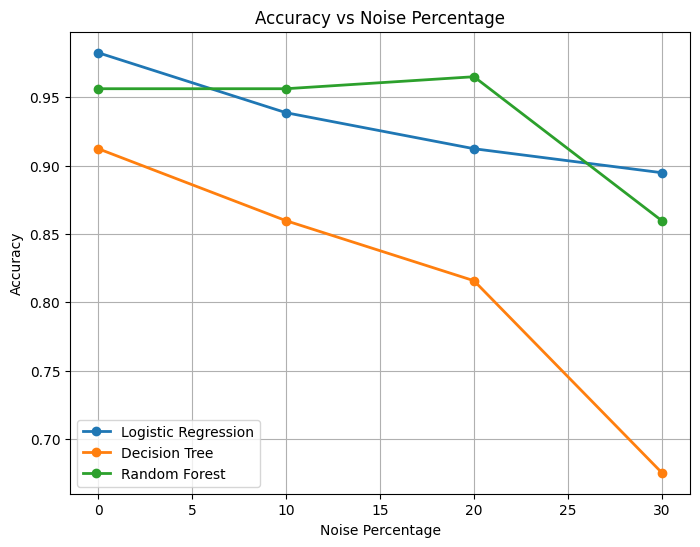

In [ ]:
plt.figure(figsize=(8,6))

for model in results_df["Model"].unique():

    subset = results_df[
        results_df["Model"] == model
    ]

    plt.plot(
        subset["Noise (%)"],
        subset["Accuracy"],
        marker="o",
        linewidth=2,
        label=model
    )

plt.title("Accuracy vs Noise Percentage")

plt.xlabel("Noise Percentage")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.savefig(
    "results/task2/accuracy_vs_noise.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()